<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/BI_tempered_logistic_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn


In [2]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from keras.layers import (
    Conv1D, MaxPooling1D, Dense, BatchNormalization,
    GlobalAveragePooling1D, Dropout, Add, Input
)
from keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from google.colab import drive

warnings.filterwarnings("ignore")

SEED = 42
N_CLASSES = 5
SIGNAL_LENGTH = 187
T1 = 0.8
T2 = 1.2
BI_TEMPERED_ITERS = 5

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


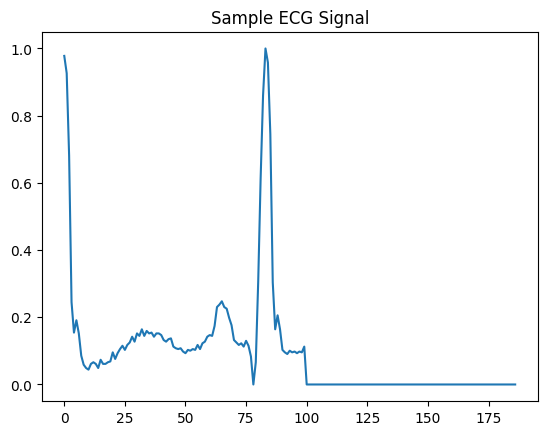

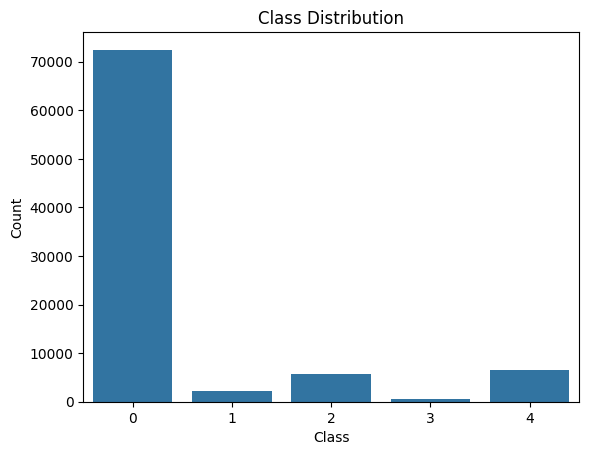

Train Missing: 0
Test Missing : 0


In [4]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()

sns.barplot(x=[0, 1, 2, 3, 4], y=counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

print("Train Missing:", train.isna().sum().sum())
print("Test Missing :", test.isna().sum().sum())


In [5]:
X = train.iloc[:, :-1].values.astype(np.float32)
y = train.iloc[:, -1].values.astype(np.int32)

X_test_raw = test.iloc[:, :-1].values.astype(np.float32)
y_test = test.iloc[:, -1].values.astype(np.int32)

def scale_smote_reshape(X_train_part, y_train_part, X_val_part=None):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_part)

    smote = SMOTE(random_state=SEED)
    X_train_balanced, y_train_balanced = smote.fit_resample(
        X_train_scaled,
        y_train_part
    )

    X_train_balanced = X_train_balanced.reshape(-1, SIGNAL_LENGTH, 1)

    if X_val_part is None:
        return X_train_balanced, y_train_balanced, scaler

    X_val_scaled = scaler.transform(X_val_part)
    X_val_scaled = X_val_scaled.reshape(-1, SIGNAL_LENGTH, 1)

    return X_train_balanced, y_train_balanced, X_val_scaled, scaler


In [6]:
def log_t(u, t):
    if t == 1.0:
        return tf.math.log(u)

    return (tf.pow(u, 1.0 - t) - 1.0) / (1.0 - t)

def exp_t(u, t):
    if t == 1.0:
        return tf.exp(u)

    return tf.pow(tf.nn.relu(1.0 + (1.0 - t) * u), 1.0 / (1.0 - t))

def compute_normalization_fixed_point(activations, t, num_iters):
    mu = tf.reduce_max(activations, axis=-1, keepdims=True)
    normalized_activations_step_0 = activations - mu
    normalized_activations = normalized_activations_step_0

    for _ in range(num_iters):
        logt_partition = tf.reduce_sum(
            exp_t(normalized_activations, t),
            axis=-1,
            keepdims=True
        )
        normalized_activations = (
            normalized_activations_step_0 * tf.pow(logt_partition, 1.0 - t)
        )

    logt_partition = tf.reduce_sum(
        exp_t(normalized_activations, t),
        axis=-1,
        keepdims=True
    )

    return -log_t(1.0 / logt_partition, t) + mu

def tempered_softmax(activations, t, num_iters):
    if t == 1.0:
        return tf.nn.softmax(activations, axis=-1)

    normalization_constants = compute_normalization_fixed_point(
        activations,
        t,
        num_iters
    )

    return exp_t(activations - normalization_constants, t)

def bi_tempered_logistic_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)

    probabilities = tempered_softmax(
        y_pred,
        T2,
        BI_TEMPERED_ITERS
    )

    loss_values = (
        y_true * (log_t(y_true + 1e-10, T1) - log_t(probabilities, T1))
        - (1.0 / (2.0 - T1))
        * (tf.pow(y_true, 2.0 - T1) - tf.pow(probabilities, 2.0 - T1))
    )

    return tf.reduce_sum(loss_values, axis=-1)


In [7]:
def resnet_block(x, filters, stride=1, weight_decay=1e-4):
    shortcut = x

    x = Conv1D(
        filters,
        3,
        strides=stride,
        padding='same',
        kernel_regularizer=l2(weight_decay)
    )(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(
        filters,
        3,
        padding='same',
        kernel_regularizer=l2(weight_decay)
    )(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(
            filters,
            1,
            strides=stride,
            padding='same',
            kernel_regularizer=l2(weight_decay)
        )(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x

def resnet_ecg(weight_decay=1e-4, dropout_rate=0.55):
    inputs = Input(shape=(SIGNAL_LENGTH, 1))

    x = Conv1D(
        32,
        3,
        activation='relu',
        kernel_regularizer=l2(weight_decay)
    )(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.15)(x)

    x = resnet_block(x, 64, weight_decay=weight_decay)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.15)(x)

    x = resnet_block(x, 128, weight_decay=weight_decay)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.20)(x)

    x = resnet_block(x, 256, weight_decay=weight_decay)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(weight_decay)
    )(x)
    x = Dropout(dropout_rate)(x)

    outputs = Dense(N_CLASSES)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=bi_tempered_logistic_loss,
        metrics=['accuracy']
    )

    return model

def get_callbacks():
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )

    return [early_stop, reduce_lr]


In [8]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

cv_accuracies = []
cv_mcc_scores = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"\nFold {fold + 1}")

    X_tr_raw, X_va_raw = X[train_idx], X[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]

    X_tr, y_tr, X_va, _ = scale_smote_reshape(X_tr_raw, y_tr, X_va_raw)
    y_tr_cat = to_categorical(y_tr, N_CLASSES)
    y_va_cat = to_categorical(y_va, N_CLASSES)

    tf.keras.backend.clear_session()
    model = resnet_ecg()

    model.fit(
        X_tr, y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=10,
        batch_size=64,
        callbacks=get_callbacks(),
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va_cat, verbose=0)
    y_va_pred = np.argmax(model.predict(X_va, verbose=0), axis=1)
    fold_mcc = matthews_corrcoef(y_va, y_va_pred)

    print(f"Fold {fold + 1} Accuracy: {acc:.4f}")
    print(f"Fold {fold + 1} MCC     : {fold_mcc:.4f}")

    cv_accuracies.append(acc)
    cv_mcc_scores.append(fold_mcc)

print("\nMean CV Accuracy:", np.mean(cv_accuracies))
print("Std CV Accuracy :", np.std(cv_accuracies))
print("Mean CV MCC     :", np.mean(cv_mcc_scores))
print("Std CV MCC      :", np.std(cv_mcc_scores))



Fold 1
Epoch 1/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 71s 13ms/step - accuracy: 0.8996 - loss: 0.2955 - val_accuracy: 0.9147 - val_loss: 0.2529 - learning_rate: 0.0010
Epoch 2/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9466 - loss: 0.1893 - val_accuracy: 0.9634 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 3/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9569 - loss: 0.1637 - val_accuracy: 0.9515 - val_loss: 0.1787 - learning_rate: 0.0010
Epoch 4/10
3770/3775 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9617 - loss: 0.1527
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9628 - loss: 0.1501 - val_accuracy: 0.9327 - val_loss: 0.2061 - learning_rate: 0.0010
Epoch 5/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9759 - loss: 0.1137 - val_accuracy: 0.9655 - val_loss: 0.1309 - learning_rate: 5.0000e-04
Epoch 6/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step

In [9]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

X_train_final, y_train_final, X_val_final, final_scaler = scale_smote_reshape(
    X_train_raw,
    y_train,
    X_val_raw
)

y_train_final_cat = to_categorical(y_train_final, N_CLASSES)
y_val_cat = to_categorical(y_val, N_CLASSES)
y_test_cat = to_categorical(y_test, N_CLASSES)

X_test = final_scaler.transform(X_test_raw)
X_test = X_test.reshape(-1, SIGNAL_LENGTH, 1)

tf.keras.backend.clear_session()
model = resnet_ecg()


In [10]:
history = model.fit(
    X_train_final, y_train_final_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)


Epoch 1/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 75s 13ms/step - accuracy: 0.9066 - loss: 0.2807 - val_accuracy: 0.9240 - val_loss: 0.2412 - learning_rate: 0.0010
Epoch 2/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.9493 - loss: 0.1819 - val_accuracy: 0.9189 - val_loss: 0.2481 - learning_rate: 0.0010
Epoch 3/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9586 - loss: 0.1585 - val_accuracy: 0.9477 - val_loss: 0.1826 - learning_rate: 0.0010
Epoch 4/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.9632 - loss: 0.1460 - val_accuracy: 0.9614 - val_loss: 0.1497 - learning_rate: 0.0010
Epoch 5/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9667 - loss: 0.1362 - val_accuracy: 0.9685 - val_loss: 0.1374 - learning_rate: 0.0010
Epoch 6/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9684 - loss: 0.1305 - val_accuracy: 0.9386 - val_loss: 0.1893 - learning_rate: 0.0010
Epoch 7/20
4524/4530 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 

Validation MCC: 0.9410078171353327


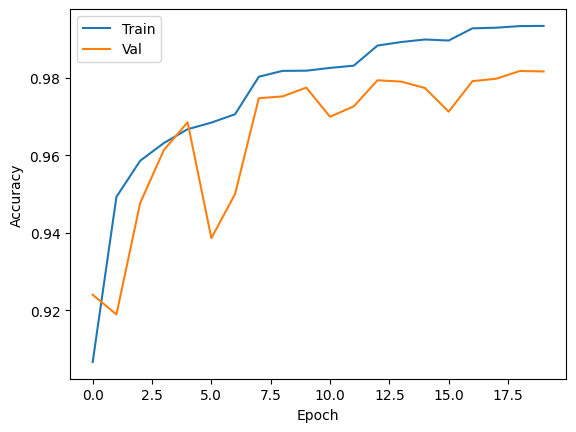

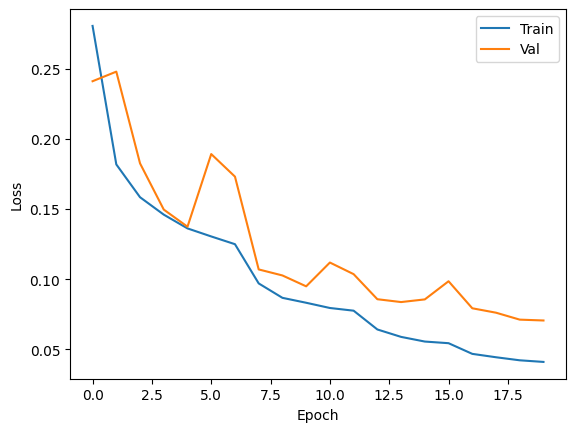

In [11]:
y_val_pred = np.argmax(model.predict(X_val_final, verbose=0), axis=1)
y_val_true = y_val

print("Validation MCC:", matthews_corrcoef(y_val_true, y_val_pred))

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Test Accuracy: 0.9794902205467224
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.70      0.84      0.77       556
           2       0.97      0.96      0.96      1448
           3       0.80      0.86      0.83       162
           4       0.98      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.89      0.93      0.91     21892
weighted avg       0.98      0.98      0.98     21892



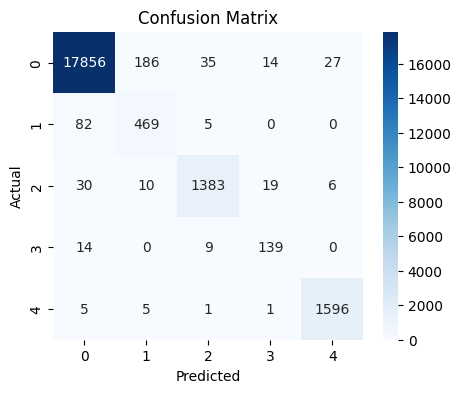

Training Accuracy   : 0.9979
Validation Accuracy : 0.9817
Testing Accuracy    : 0.9795
Training Loss       : 0.0307
Validation Loss     : 0.0705
Testing Loss        : 0.0751
Testing MCC         : 0.9339


In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

train_loss, train_acc = model.evaluate(
    X_train_final,
    y_train_final_cat,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val_final,
    y_val_cat,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

test_mcc = matthews_corrcoef(y_test, y_test_pred)

print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Testing Accuracy    : {test_acc:.4f}")

print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Testing Loss        : {test_loss:.4f}")

print(f"Testing MCC         : {test_mcc:.4f}")
